# Explore Muon Theoretical Lifetime in Argon
### --Created by Shu, 20250417

#### Doule exponential fitting:

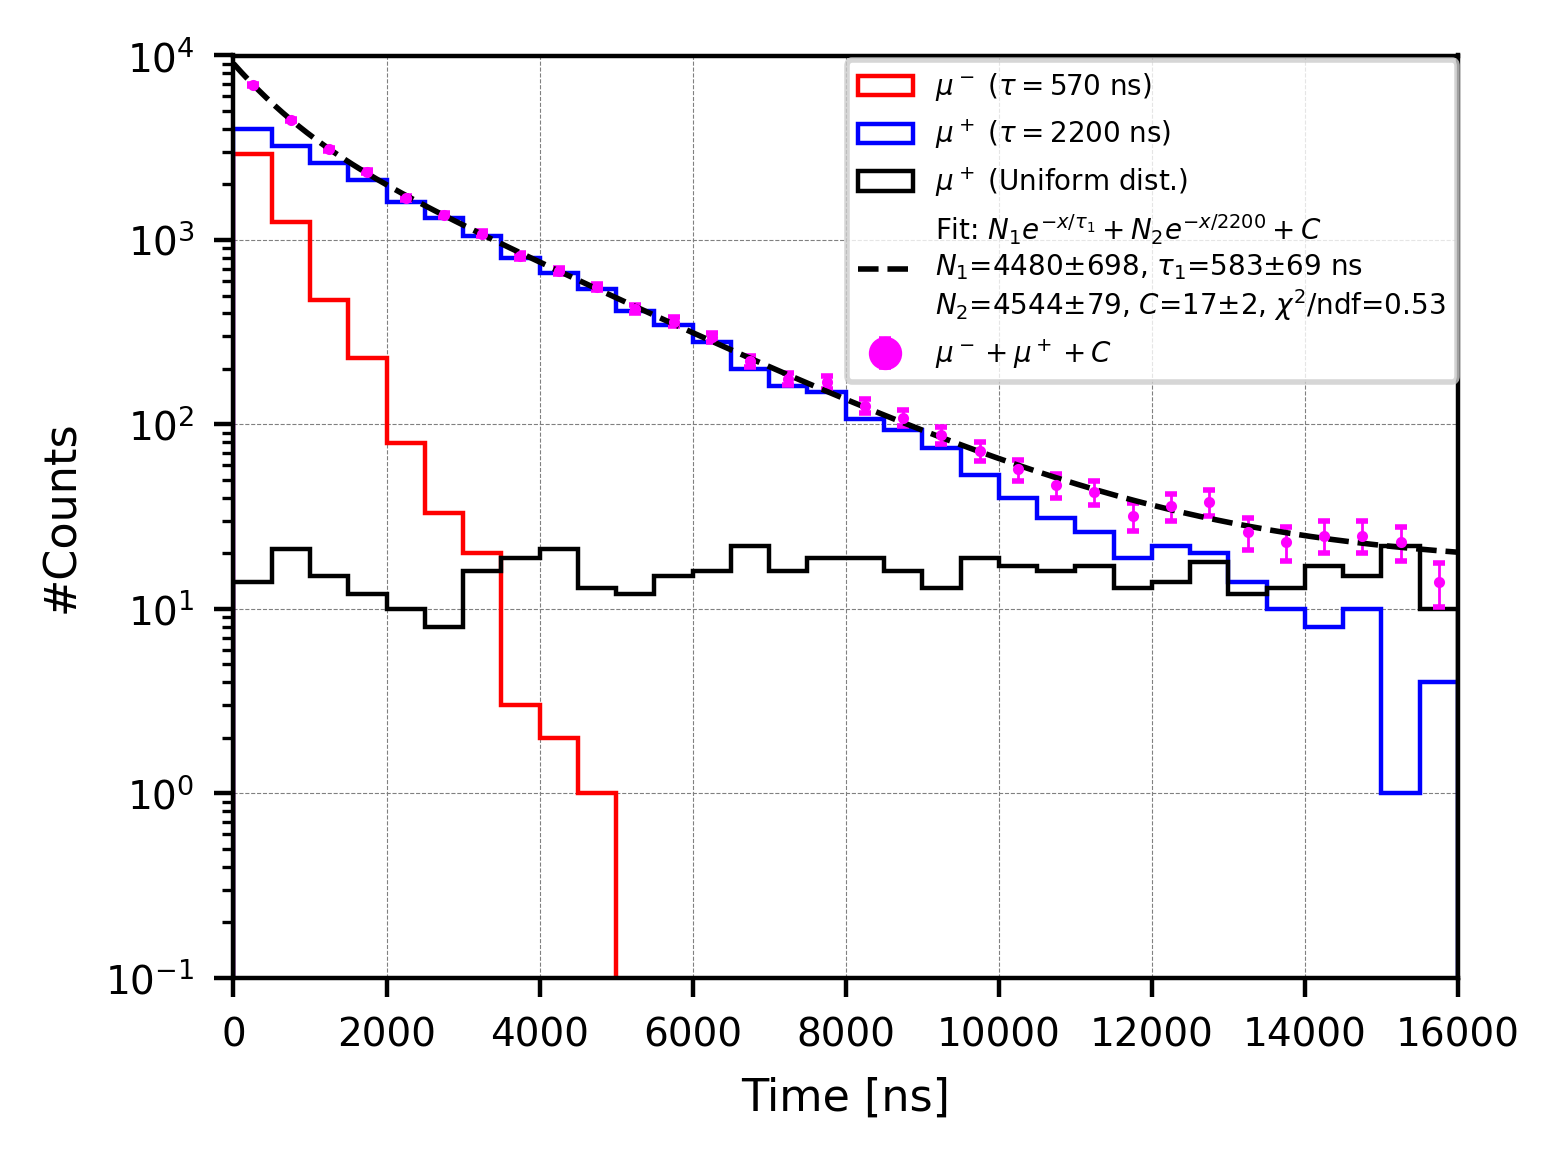


Fitted parameters:
  N1    = 4479.6 ± 697.8
  tau1  = 583 ± 69 ns
  N2    = 4544.0 ± 78.9
  C     = 17.1 ± 1.7
  Chi² / ndf = 13.8 / 26 = 0.53

Bin Center [ns]   Counts   Error
     250.0        6922     83.20
     750.0        4483     66.96
    1250.0        3104     55.71
    1750.0        2350     48.48
    2250.0        1689     41.10
    2750.0        1363     36.92
    3250.0        1082     32.89
    3750.0         822     28.67
    4250.0         683     26.13
    4750.0         557     23.60
    5250.0         424     20.59
    5750.0         361     19.00
    6250.0         297     17.23
    6750.0         221     14.87
    7250.0         177     13.30
    7750.0         169     13.00
    8250.0         126     11.22
    8750.0         109     10.44
    9250.0          88      9.38
    9750.0          72      8.49
   10250.0          57      7.55
   10750.0          47      6.86
   11250.0          43      6.56
   11750.0          32      5.66
   12250.0          36      6.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate samples------------------------------------------
np.random.seed(42)

# Define time constants (in ns)
tau_A = 570   # ns
tau_B = 2200  # ns

# Generate samples--------
n_A = 5000
n_B = 20000
samples_A = np.random.exponential(scale=tau_A, size=n_A)
samples_B = np.random.exponential(scale=tau_B, size=n_B)
n_C = 500  # for example
samples_C = np.random.uniform(0, 16000, n_C)

# Plot the histograms------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define a common bin width
bin_width = 500  # ns
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histogram values
hist_A, bin_edges_A = np.histogram(samples_A, bins=bins, range=(range_min, range_max))
hist_B, bin_edges_B = np.histogram(samples_B, bins=bins, range=(range_min, range_max))
hist_C, bin_edges_C = np.histogram(samples_C, bins=bins, range=(range_min, range_max))

# Sum of all histograms
sum_hist = hist_A + hist_B + hist_C
bin_centers = (bin_edges_A[:-1] + bin_edges_A[1:]) / 2
sum_err = np.sqrt(sum_hist)

# Define new fitting function with offset C
def double_exp_decay(x, N1, tau1, N2, C):
    return N1 * np.exp(-x / tau1) + N2 * np.exp(-x / 2200) + C

# Mask bins with zero counts within the range [500, 15500]
mask = (bin_centers >= 500) & (bin_centers <= 15500) & (sum_hist > 0)
fit_x = bin_centers[mask]
fit_y = sum_hist[mask]
fit_err = sum_err[mask]

# Initial guess for parameters
initial_guess = [2000, 500, 8000, 0]  # N1, tau1, N2, C
popt, pcov = curve_fit(double_exp_decay, fit_x, fit_y, p0=initial_guess, sigma=fit_err, absolute_sigma=True)
N1_fit, tau1_fit, N2_fit, C_fit = popt
N1_err, tau1_err, N2_err, C_err = np.sqrt(np.diag(pcov))

# Compute chi-squared---------------
fit_model = double_exp_decay(fit_x, *popt)
chi2 = np.sum(((fit_y - fit_model) / fit_err) ** 2)
ndf = len(fit_y) - len(popt)
chi2_ndf = chi2 / ndf

# Drawing of initial plots----------
plt.hist(samples_A, bins=bins, histtype='step', color='red', linewidth=0.8, label='$\\mu^-$ ($\\tau = 570$ ns)')
plt.hist(samples_B, bins=bins, histtype='step', color='blue', linewidth=0.8, label='$\\mu^+$ ($\\tau = 2200$ ns)')
plt.hist(samples_C, bins=bins, histtype='step', color='black', linewidth=0.8, label='$\\mu^+$ (Uniform dist.)')
plt.errorbar(bin_centers, sum_hist, yerr=sum_err, fmt='o', color='magenta',
             markersize=1, elinewidth=0.5, capsize=1.0, label='$\\mu^- + \\mu^+ + C$')

# Plot the fitted curve-------------
x_fit_line = np.linspace(0, 16000, 300)
y_fit_line = double_exp_decay(x_fit_line, *popt)
plt.plot(x_fit_line, y_fit_line, 'k--', linewidth=1.0,
         label=f'Fit: $N_1 e^{{-x/\\tau_1}} + N_2 e^{{-x/2200}} + C$\n'
               f'$N_1$={N1_fit:.0f}±{N1_err:.0f}, $\\tau_1$={tau1_fit:.0f}±{tau1_err:.0f} ns\n'
               f'$N_2$={N2_fit:.0f}±{N2_err:.0f}, $C$={C_fit:.0f}±{C_err:.0f}, $\\chi^2$/ndf={chi2_ndf:.2f}')

# Axes settings-------------------
plt.xlim(0, 16000)
plt.ylim(0.1, 10000)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 1.01), fontsize=8, markerscale=5, ncol=1, prop={'size': 5})
plt.tight_layout()
plt.show()

# Print fit results----------
print(f"\nFitted parameters:")
print(f"  N1    = {N1_fit:.1f} ± {N1_err:.1f}")
print(f"  tau1  = {tau1_fit:.0f} ± {tau1_err:.0f} ns")
print(f"  N2    = {N2_fit:.1f} ± {N2_err:.1f}")
print(f"  C     = {C_fit:.1f} ± {C_err:.1f}")
print(f"  Chi² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print bin center, count, and error----------
print("\nBin Center [ns]   Counts   Error")
for center, count, error in zip(bin_centers, sum_hist, sum_err):
    print(f"{center:10.1f}      {count:6d}   {error:7.2f}")


<br />
<br />
<br />

#### Single exponential fitting:

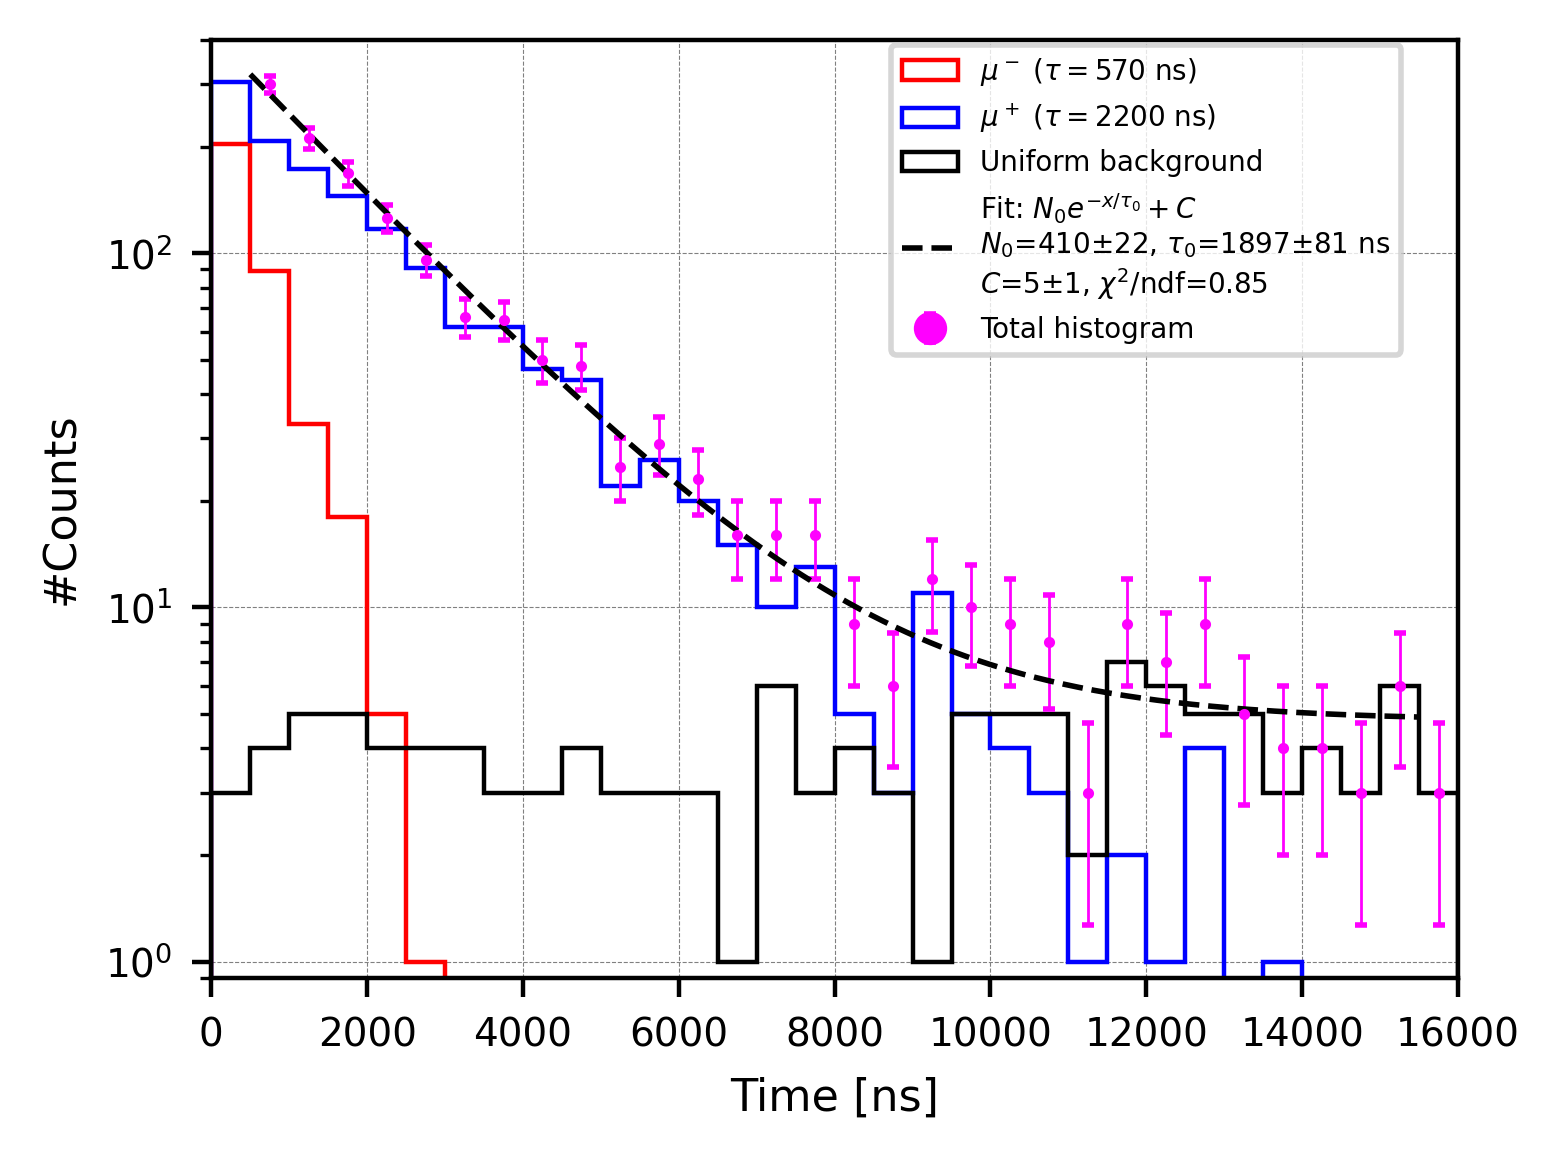


Fitted parameters:
  N0    = 410.3 ± 22.4
  tau0  = 1897 ± 81 ns
  C     = 4.8 ± 0.7
  Chi² / ndf = 22.8 / 27 = 0.85

Bin Center [ns]   Counts   Error
     250.0         511     22.61
     750.0         300     17.32
    1250.0         211     14.53
    1750.0         168     12.96
    2250.0         126     11.22
    2750.0          96      9.80
    3250.0          66      8.12
    3750.0          65      8.06
    4250.0          50      7.07
    4750.0          48      6.93
    5250.0          25      5.00
    5750.0          29      5.39
    6250.0          23      4.80
    6750.0          16      4.00
    7250.0          16      4.00
    7750.0          16      4.00
    8250.0           9      3.00
    8750.0           6      2.45
    9250.0          12      3.46
    9750.0          10      3.16
   10250.0           9      3.00
   10750.0           8      2.83
   11250.0           3      1.73
   11750.0           9      3.00
   12250.0           7      2.65
   12750.0           9 

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate samples------------------------------------------
np.random.seed(42)

# Define time constants (in ns)
tau_A = 570   # ns
tau_B = 2200  # ns

# Generate samples--------
n_A = 350
n_B = 1400
samples_A = np.random.exponential(scale=tau_A, size=n_A)
samples_B = np.random.exponential(scale=tau_B, size=n_B)
n_C = 125  # for example
samples_C = np.random.uniform(0, 16000, n_C)

# Plot the histograms------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define a common bin width
bin_width = 500  # ns
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histogram values
hist_A, bin_edges_A = np.histogram(samples_A, bins=bins, range=(range_min, range_max))
hist_B, bin_edges_B = np.histogram(samples_B, bins=bins, range=(range_min, range_max))
hist_C, bin_edges_C = np.histogram(samples_C, bins=bins, range=(range_min, range_max))

# Sum of all histograms
sum_hist = hist_A + hist_B + hist_C
bin_centers = (bin_edges_A[:-1] + bin_edges_A[1:]) / 2
sum_err = np.sqrt(sum_hist)

# Define the fitting function
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Fit only within [500, 15500] and where counts > 0
fit_mask = (bin_centers >= 500) & (bin_centers <= 15500) & (sum_hist > 0)
fit_x = bin_centers[fit_mask]
fit_y = sum_hist[fit_mask]
fit_err = sum_err[fit_mask]

# Initial guess for parameters
initial_guess = [8000, 1000, 100]  # N0, tau0, C
popt, pcov = curve_fit(exp_func, fit_x, fit_y, p0=initial_guess, sigma=fit_err, absolute_sigma=True)
N0_fit, tau0_fit, C_fit = popt
N0_err, tau0_err, C_err = np.sqrt(np.diag(pcov))

# Compute chi-squared---------------
fit_model = exp_func(fit_x, *popt)
chi2 = np.sum(((fit_y - fit_model) / fit_err) ** 2)
ndf = len(fit_y) - len(popt)
chi2_ndf = chi2 / ndf

# Draw histograms of components and total
plt.hist(samples_A, bins=bins, histtype='step', color='red', linewidth=0.8, label='$\\mu^-$ ($\\tau = 570$ ns)')
plt.hist(samples_B, bins=bins, histtype='step', color='blue', linewidth=0.8, label='$\\mu^+$ ($\\tau = 2200$ ns)')
plt.hist(samples_C, bins=bins, histtype='step', color='black', linewidth=0.8, label='Uniform background')
plt.errorbar(bin_centers, sum_hist, yerr=sum_err, fmt='o', color='magenta',
             markersize=1, elinewidth=0.5, capsize=1.0, label='Total histogram')

# Plot the fitted curve in [500, 15500] only
x_fit_line = np.linspace(500, 15500, 300)
y_fit_line = exp_func(x_fit_line, *popt)
plt.plot(x_fit_line, y_fit_line, 'k--', linewidth=1.0,
         label=f'Fit: $N_0 e^{{-x/\\tau_0}} + C$\n'
               f'$N_0$={N0_fit:.0f}±{N0_err:.0f}, $\\tau_0$={tau0_fit:.0f}±{tau0_err:.0f} ns\n'
               f'$C$={C_fit:.0f}±{C_err:.0f}, $\\chi^2$/ndf={chi2_ndf:.2f}')

# Axes settings-------------------
plt.xlim(0, 16000)
plt.ylim(0.9, 400)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 1.01), fontsize=8, markerscale=5, ncol=1, prop={'size': 5})
plt.tight_layout()
plt.show()

# Print fit results----------
print(f"\nFitted parameters:")
print(f"  N0    = {N0_fit:.1f} ± {N0_err:.1f}")
print(f"  tau0  = {tau0_fit:.0f} ± {tau0_err:.0f} ns")
print(f"  C     = {C_fit:.1f} ± {C_err:.1f}")
print(f"  Chi² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print bin center, count, and error----------
print("\nBin Center [ns]   Counts   Error")
for center, count, error in zip(bin_centers, sum_hist, sum_err):
    print(f"{center:10.1f}      {count:6d}   {error:7.2f}")
